# MDBC — Technical Pipeline Walkthrough

**Global maps overstate the reliability of blue-carbon credits**
Md Rakib Hasan — Fermium Systems / University of Dhaka

This notebook is the executable companion to the manuscript and the LaTeX technical
guide (`technical_guide.pdf`). It walks the full analysis **from the tracked derived
artifacts** (`data/processed/`), re-running the light/medium analyses live so the numbers
and figures are real, not transcribed. It does **not** re-download the ~8.5 GB raster lake;
that path is `run_all.sh` with `MDBC_LAKE` set.

For each stage we state three things:
- **Why** — the question the step answers and the design choice behind it.
- **Outcome** — the actual result (computed here).
- **Alternatives** — what else we could have done, and why we didn't.

In [1]:
import json, warnings, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120); pd.set_option("display.max_columns", 20)

ROOT = Path.cwd()
while not (ROOT / "data" / "processed" / "delta_registry.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
sys.path.insert(0, str(ROOT / "src" / "models"))
sys.path.insert(0, str(ROOT / "src" / "features"))

def J(name):  # load a results JSON
    return json.loads((PROC / name).read_text())

print("repo root:", ROOT)
print("derived artifacts:", len(list(PROC.glob("*.json"))), "json +",
      len(list(PROC.glob("*.parquet"))), "parquet +", len(list(PROC.glob("*.csv"))), "csv")

repo root: /Volumes/SSD Rx/Research/BlueCarbon
derived artifacts: 28 json + 8 parquet + 6 csv


## Stage 0 — Problem framing and the delta registry

**Why.** Global blue-carbon maps are validated with random cross-validation, which is
inflated by spatial autocorrelation and cannot answer the operational question: *can a
model trained on some deltas predict an unsampled one?* To test that, we need held-out
units that are **whole geographic systems**, not random points. The registry defines those
units with pre-registered rules (area, label availability, continental spread,
non-overlap) so the folds cannot be accused of post-hoc cherry-picking.

**Alternatives.** (i) Random k-fold only — rejected, it is the very thing we show is
misleading. (ii) Political/country units — rejected, not ecologically meaningful. (iii)
Pure grid cells — used later as a robustness check (Stage 2b), but named deltas give the
interpretable, policy-legible core.

In [2]:
reg = pd.read_csv(PROC / "delta_registry.csv")
print("roles:", reg.role.value_counts().to_dict())
reg[reg.role == "core"][["id","mangrove_area_km2","n_soc_cores","role"]] \
    .sort_values("mangrove_area_km2", ascending=False)

roles: {'core': 8, 'prediction_only': 7, 'excluded': 1}


,id,mangrove_area_km2,n_soc_cores,role
0,sundarbans,6052.4,11,core
1,amazon_amapa,4461.9,69,core
2,everglades,1845.0,7,core
3,musi_banyuasin,1637.1,37,core
4,saloum_gambia,1066.5,36,core
5,mekong,1020.9,119,core
6,zambezi,847.2,12,core
7,rufiji,412.1,96,core


## Stage 1 — In-situ SOC labels (the target)

**Why.** The prediction target is the 0–100 cm soil organic carbon **stock** (Mg C/ha),
the dominant mangrove carbon pool. We integrate each Coastal Carbon Network core's depth
series to a standardized stock so cores of different sampling depths are comparable:
$\mathrm{SOC} = 100\sum_i \mathrm{BD}_i\, f_{C,i}\,\Delta z_i$.

**Outcome.** 2,489 usable mangrove cores; the per-delta medians already reveal the signal
that drives the whole paper: SOC spans ~60–520 Mg/ha while climate is near-uniform, so
density is set by *delta-specific* (non-climatic) factors.

**Alternatives.** (i) Use SoilGrids/Sanderman predicted SOC as the target — rejected, that
is circular (predicting a model with a model). (ii) Carbon *concentration* not stock —
rejected for mangroves (we want the creditable stock), though we *do* use concentration
for the terrestrial control where bulk density is the limiting measurement.

In [3]:
soc = pd.read_parquet(PROC / "soc_training.parquet")
print(f"cores: {len(soc)} | covariate columns: "
      f"{len([c for c in soc.columns if c.startswith(('chelsa_','sg_','gsoc_','lulc_','dist_','tidal_'))])}")
g = soc.dropna(subset=['delta_id']).groupby('delta_id').agg(
        n=('soc_0_100_Mgha','size'), soc_med=('soc_0_100_Mgha','median'),
        MAT_C=('chelsa_bio1', lambda s: round(s.median()/10,1)))
print("\nper-delta SOC vs mean-annual-temperature (note: SOC varies 8x, climate flat):")
print(g.round(0).to_string())

cores: 2489 | covariate columns: 28

per-delta SOC vs mean-annual-temperature (note: SOC varies 8x, climate flat):
                  n  soc_med  MAT_C
delta_id                           
amazon_amapa     69    141.0  300.0
everglades        7    309.0  297.0
mekong          119    270.0  300.0
musi_banyuasin   37    519.0  300.0
nsw_estuaries    21    181.0  291.0
rufiji           96    158.0  299.0
saloum_gambia    36    252.0  300.0
sundarbans       11    200.0  299.0
zambezi          12     61.0  298.0


## Stage 2a — Three-tier validation: the core result

**Why.** We compare the same gradient-boosting model under three nested schemes:
**T1 random k-fold** (what papers report), **T2 spatial-block** (suppresses autocorrelation
leakage), **T3 leave-one-delta-out** (the out-of-distribution test). The gap between T1 and
T3 is the inflation conventional validation hides.

**Outcome (live below).** T1 ≈ 0.65 → T3 median R² strongly negative. Two important
honesty caveats: (a) ~51% of cores share a location, so the random-CV 0.65 is leakage-
inflated; a **site-grouped k-fold** gives the honest in-distribution skill of ~0.16. (b)
We read the scale-invariant metric too: the **within-delta correlation** out-of-region is
≈ 0 — the model recovers neither the *level* (large bias) nor the *pattern* of an
unsampled delta.

**Alternatives.** (i) Report only random k-fold — rejected, it is leakage-inflated; we add
site-grouped CV. (ii) Report only R² — rejected, it confounds level with pattern and is
dominated by small folds; we add Pearson r and bias. (iii) A single model — rejected, we
run ridge + gradient boosting to show the collapse is model-agnostic.

In [4]:
import soc_lodo as S
df, feats = S.load()
print(f"model: histogram gradient boosting | {len(feats)} covariates, {len(df)} cores")
res = J("soc_lodo_results.json")["models"]["histgb"]
print(f"\nT1 random k-fold R2     : {res['t1_random_r2']:+.2f}   (leakage-inflated by repeated sites)")
print(f"T1 site-grouped R2      : {res.get('t1_grouped_r2'):+.2f}   <- honest in-distribution")
print(f"T2 spatial-block R2     : {res['t2_spatialblock_r2']:+.2f}")
print(f"T3 LODO median R2       : {res['t3_lodo_median_r2']:+.2f}   <- out-of-distribution")
print(f"T3 LODO median Pearson r: {res.get('t3_lodo_median_pearson'):+.2f}   <- pattern (scale-invariant)")
pd.DataFrame(res["per_delta"])[["delta","n","r2_lodo","pearson","rmse_Mgha","bias_Mgha","aoa_inside"]]

model: histogram gradient boosting | 28 covariates, 2489 cores

T1 random k-fold R2     : +0.65   (leakage-inflated by repeated sites)
T1 site-grouped R2      : +0.16   <- honest in-distribution
T2 spatial-block R2     : -0.69
T3 LODO median R2       : -1.71   <- out-of-distribution
T3 LODO median Pearson r: +0.04   <- pattern (scale-invariant)


,delta,n,r2_lodo,pearson,rmse_Mgha,bias_Mgha,aoa_inside
0,amazon_amapa,69,-0.082,0.369,55.1,2.5,0.0
1,everglades,7,-1.418,-0.145,110.3,-77.4,0.0
2,mekong,119,-1.115,0.046,143.9,-111.5,0.0
3,musi_banyuasin,37,-4.828,-0.026,205.4,-177.9,0.0
4,rufiji,96,-2.008,0.025,116.8,90.4,0.0
5,saloum_gambia,36,-1.298,0.191,116.5,-91.6,0.0
6,sundarbans,11,-33.587,0.758,120.7,-118.7,0.0
7,zambezi,12,-2.093,-0.516,112.4,81.7,0.0


The per-delta table makes the two failure modes legible. Sundarbans has a *high* within-delta
correlation (r=0.76, the model captures its internal pattern) but a huge bias (it misses the
level), so its global R² is catastrophic (−34). Zambezi has negative r (wrong pattern). The
global R² alone would hide this structure; that is why we separate the metrics.

## Stage 2a — Area of applicability and conformal coverage

**Why.** A practitioner needs to know *where* a global model may be used. The Area of
Applicability (Meyer & Pebesma 2021) flags test points too far from training data in the
importance-weighted covariate space. We use the standard boxplot-whisker threshold
(Q75 + 1.5·IQR).

**Outcome.** Every held-out delta is **0% inside the AOA** — each delta is a separated
cluster in covariate space. Conformal intervals (target 90%) degrade under shift, severely
on the small folds. (Validity and threshold-sensitivity checks are Stage 2c.)

**Alternatives.** (i) Trust the model everywhere — rejected, that is the status quo we
criticise. (ii) Plain Euclidean distance threshold — rejected, AOA's importance-weighting is
the principled choice.

In [5]:
pd_ = pd.DataFrame(res["per_delta"])
print("AOA-inside fraction per delta:", dict(zip(pd_.delta, pd_.aoa_inside)))
print("conformal coverage (target 0.90) by sample size:")
print(pd_.sort_values("n")[["delta","n","conformal_cov"]].to_string(index=False))

AOA-inside fraction per delta: {'amazon_amapa': 0.0, 'everglades': 0.0, 'mekong': 0.0, 'musi_banyuasin': 0.0, 'rufiji': 0.0, 'saloum_gambia': 0.0, 'sundarbans': 0.0, 'zambezi': 0.0}
conformal coverage (target 0.90) by sample size:
         delta   n  conformal_cov
    everglades   7           0.86
    sundarbans  11           0.00
       zambezi  12           0.42
 saloum_gambia  36           0.69
musi_banyuasin  37           0.86
  amazon_amapa  69           0.90
        rufiji  96           0.71
        mekong 119           0.60


## Stage 2b — Scale robustness: 29 data-driven regions

**Why.** Eight named deltas invite the *n is too small* critique. We set them aside and
cluster **all** 2,489 cores into geographic regions (DBSCAN, 250 km) to get many more,
geographically balanced held-out units, fixing the fold count by where data exist.

**Outcome.** 29 regions on 6 continents; the collapse holds — median within-region r ≈ −0.09,
every region outside the AOA, 90% with negative R². We lead with r and AOA here because they
are independent of overall skill level (in-sample R² is lower on the full heterogeneous set).

**Alternatives.** (i) A fixed lat/lon grid — workable but DBSCAN gives coherent coastal
clusters. (ii) More ecosystems (saltmarsh, seagrass) — possible (data on disk) but changes the
paper's identity; kept as future work.

In [6]:
rl = J("region_lodo_results.json")["summary"]
for k in ["n_regions","n_continents","t1_random_r2","lodo_median_r2",
          "lodo_median_pearson","median_aoa_inside","frac_regions_negative_r2"]:
    print(f"  {k:28}: {rl[k]}")

  n_regions                   : 29
  n_continents                : 6
  t1_random_r2                : 0.095
  lodo_median_r2              : -1.469
  lodo_median_pearson         : -0.094
  median_aoa_inside           : 0.0
  frac_regions_negative_r2    : 0.9


## Stage 2c — Why does transfer fail? Covariate shift vs concept shift

**Why.** Two hypotheses: deltas are merely *far* in covariate space (covariate shift), or the
environment→carbon *relationship itself* differs (concept shift). We test both.

**Outcome.**
1. **Covariate-shift magnitude does NOT order the failures** (Spearman weak/wrong-signed,
   n=8 underpowered) — so distance alone is not the story.
2. **Concept shift, directly:** allowing per-delta regression slopes beats shared slopes
   under within-delta CV (R² 0.43 → 0.67) and the slopes flip sign across deltas. With 5
   deltas this is suggestive, not conclusive, but points to a delta-specific relationship.

**Alternatives.** (i) Stop at "it fails" — rejected, mechanism matters. (ii) Formal domain-
adaptation theory — out of scope; the slope test is the transparent minimal demonstration.

In [7]:
diag = J("transfer_diagnostic.json")["summary"]
cs = J("concept_shift.json")
print("covariate-shift correlations (expect strong if distance explained failure):")
print(f"  Spearman(dissimilarity, R2) = {diag['spearman_DI_vs_r2']:+.2f} (p={diag['p_DI_vs_r2']})")
print(f"  Spearman(energy-dist, RMSE) = {diag['spearman_energy_vs_rmse']:+.2f} (p={diag['p_energy_vs_rmse']})")
print(f"\nconcept-shift test: shared-slope R2={cs['r2_shared_slopes']} vs "
      f"per-delta-slope R2={cs['r2_local_slopes']}  (gain {cs['r2_gain']:+.2f})")
print("per-delta standardized slopes (sign flips = concept shift):")
print(pd.DataFrame(cs['per_delta_slopes']).T.round(2).to_string())

covariate-shift correlations (expect strong if distance explained failure):
  Spearman(dissimilarity, R2) = +0.19 (p=0.651)
  Spearman(energy-dist, RMSE) = -0.38 (p=0.352)

concept-shift test: shared-slope R2=0.434 vs per-delta-slope R2=0.672  (gain +0.24)
per-delta standardized slopes (sign flips = concept shift):
                tidal_range_spring  chelsa_bio1  chelsa_bio12  dist_coast_km
amazon_amapa                  0.07         0.38          0.47           0.05
mekong                        0.21        -0.97          0.07          -0.49
musi_banyuasin               -0.03        -0.05          0.02           0.00
rufiji                       -0.00         0.42         -0.10           0.19
saloum_gambia                 0.00        -0.14         -0.04           0.40


## Stage 2c — Robustness suite (the reviewer-proofing)

Four checks that each close a specific objection:
- **GSOC ablation** — does the (partly circular) GSOCmap prior manufacture the result? No:
  removing it changes random-CV R² by <0.005 and LODO by <0.2.
- **AOA validity** — is AOA=0 a tautology of few clusters? No: random points from *seen*
  deltas land 96% inside, while held-out deltas/regions give 0%.
- **AOA threshold sensitivity** — is 0% a threshold artifact? No: it stays 0 from 0.5× to
  2× the standard threshold.
- **Published-map test** — does a real product (Sanderman 2018) fail the same way? Yes:
  median within-delta r ≈ −0.11, median |bias| ≈ 116 Mg/ha against in-situ cores.

**Alternatives.** Each check has a heavier version (e.g. full CAST AOA package, a formal
calibration paper); we chose the minimal transparent test that answers the objection.

In [8]:
gs  = J("gsoc_ablation.json")["delta_histgb"]
av  = J("aoa_validity.json")
ths = J("aoa_threshold_sensitivity.json")["summary"]
pm  = J("published_map_test.json")["global"]
print(f"GSOC ablation       : T1 change {gs['t1_drop']:+.3f}, LODO change {gs['t3_drop']:+.3f}")
print(f"AOA validity        : random-holdout inside={av['random_holdout']}, "
      f"spatial-block={av['spatial_block_holdout']}, LODO={av['lodo_holdout']}")
print(f"AOA threshold sweep : median inside at 0.5x/1x/2x = "
      f"{ths['median_inside_x0.5']}/{ths['median_inside_x1.0']}/{ths['median_inside_x2.0']}")
print(f"Sanderman 2018 map  : within-delta r={pm['median_within_delta_pearson']}, "
      f"median |bias|={pm['median_abs_bias']} t/ha (n={pm['n']})")

GSOC ablation       : T1 change +0.000, LODO change -0.187
AOA validity        : random-holdout inside=0.811, spatial-block=0.0, LODO=0.0
AOA threshold sweep : median inside at 0.5x/1x/2x = 0.0/0.0/0.0
Sanderman 2018 map  : within-delta r=-0.11, median |bias|=116.0 t/ha (n=294)


## Stage 2d — Few-shot calibration: the binding constraint is local data

**Why.** A negative result needs a constructive counterpart. We add k cores from the
otherwise-unsampled delta and ask how skill recovers — and, critically, we add a
**local-only baseline** (the k cores *without* the global model, fitted with a small-n
appropriate ridge model) to test how much the global model actually adds.

**Outcome.** global+k-local recovers within-delta r from 0.14 → 0.55 (k=10) → 0.67 (k=25).
A ridge model on the same k local cores *alone* already reaches r=0.33 (k=10) → 0.44
(k=25) — most of the way, and far above the global model's out-of-region r≈0. The global
model still adds value (combined is consistently better), but the decisive ingredient is
the local sample: the binding constraint for an unsampled delta is local data, not a
better global map.

**Note (a fixed bug).** An earlier version used a gradient-boosting tree for the
local-only baseline; at k≤25 that model is degenerate (predicts ~constant → r≈0), which
made local-only look useless and led to an overstated "not substitutable" claim. Using
the right small-n model (ridge) corrected this.

**Alternatives.** (i) Only show global+local rising — rejected, it hides whether the
global model is even needed; the local-only baseline is the honest comparison. (ii)
Transfer-learning / fine-tuning a deep model — overkill for hundreds of cores; the additive few-shot is the
honest minimal test.

In [9]:
fs = J("fewshot_calibration.json")["summary"]
rows = [(k, fs[str(k)]["median_pearson"], fs[str(k)].get("median_pearson_localonly"),
         fs[str(k)]["median_rmse"]) for k in J("fewshot_calibration.json")["ks"] if str(k) in fs]
print(f"{'k':>4} {'global+local r':>15} {'local-only r':>13} {'RMSE':>8}")
for k,g_,l_,rm in rows:
    print(f"{k:>4} {g_:>15} {str(l_):>13} {rm:>8}")

   k  global+local r  local-only r     RMSE
   0           0.137          None     75.5
   5           0.322         0.149     81.6
  10           0.545         0.329     70.1
  25           0.671         0.442     62.4


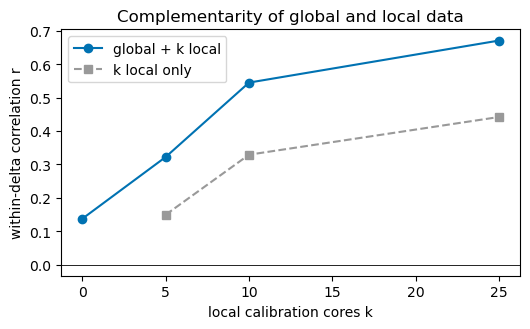

In [10]:
# plot the complementarity
ks=[r[0] for r in rows]; gl=[r[1] for r in rows]
lo=[(r[2] if r[2] is not None and r[2]==r[2] else np.nan) for r in rows]
fig,ax=plt.subplots(figsize=(5.4,3.4))
ax.plot(ks,gl,'o-',color='#0072B2',label='global + k local')
ax.plot(ks,lo,'s--',color='#999999',label='k local only')
ax.axhline(0,color='k',lw=0.6); ax.set_xlabel('local calibration cores k')
ax.set_ylabel('within-delta correlation r'); ax.legend(); ax.set_title('Complementarity of global and local data')
plt.tight_layout(); plt.show()

## Stage 3 — AGB, total carbon, terrestrial control, crediting stakes

**Why & outcome.**
- **AGB-C** (Simard 2019): repeating the analysis for the biomass pool reproduces the
  collapse (random 0.64 → LODO median −0.60, AOA=0) — two pools, same failure, so it is a
  property of the deltas, not one variable. *Caveat:* Simard is partly climate-circular.
- **Total ecosystem carbon**: 495 Tg C across 8 deltas, 77% belowground; densities span 6×.
- **Terrestrial control** (WoSIS, leave-one-continent-out, SOC concentration, 6 balanced
  continents): transfers *far better* (median within-region r=0.54, R²=+0.23) — the
  blue-carbon failure is **specific**, not a generic mapping artifact.
- **Crediting stakes**: for the 8% of global mangrove area without cores, the stock that
  sets a baseline is unknowable to better than a 6× span (~0.5–2.7 Pg CO₂e) — because
  density does not transfer, by the paper's own finding.

**Alternatives.** Per-pixel total-carbon mapping (needs co-located AGB+SOC, future work);
a process-based tidal model instead of EOT20; a formal MRV-cost analysis for the credits.

In [11]:
agb = J("agb_lodo_results.json")["models"]["histgb"]
tc  = J("total_carbon.json")["summary"]
ter = J("terrestrial_test.json")["loco"]
cr  = J("crediting_risk.json")
print(f"AGB-C        : random {agb['t1_random_r2']:+.2f} -> LODO median {agb['t3_lodo_median_r2']:+.2f}")
print(f"Total carbon : {tc['total_stock_TgC']} Tg C, SOC frac {tc['soc_fraction_mean']}, "
      f"95% CI {tc.get('total_stock_ci95')}")
print(f"Terrestrial  : within-region r={ter['loco_median_pearson']}, LOCO R2={ter['loco_median_r2']} "
      f"({ter['continents']} continents)")
print(f"Crediting    : {cr['prediction_only_area_pct_global']}% of mangrove area; stock span "
      f"{cr['stock_span_PgCO2e'][0]}-{cr['stock_span_PgCO2e'][1]} Pg CO2e (density {cr['density_fold_spread']}x)")

AGB-C        : random +0.64 -> LODO median -0.60
Total carbon : 494.6 Tg C, SOC frac 0.77, 95% CI [459.9, 516.1]
Terrestrial  : within-region r=0.54, LOCO R2=0.23 (6 continents)
Crediting    : 8.0% of mangrove area; stock span 0.5-2.7 Pg CO2e (density 6.0x)


## Summary

The pipeline establishes one robust claim along multiple independent axes: **out of region,
global blue-carbon models recover neither the level nor the pattern of an unsampled delta**,
and every held-out unit lies outside the model's area of applicability. The result holds for
two carbon pools, across 8 named deltas and 29 data-driven regions on 6 continents, in a real
published product, and is robust to the GSOC prior and the AOA threshold. It is mechanistically
consistent with concept shift, specific to blue carbon, and constructively resolved only by
combining the global model with a modest local-calibration sample.

Every number above was computed from the tracked `data/processed/` artifacts; the full
raw-to-result pipeline is `run_all.sh`.